# Data 002: replication-control results

Under the frozen two-dataset, two-model scarcity protocol, Gaussian Copula augmentation added no predictive value beyond deterministic class-preserving replication: it was practically harmful in 10 of 18 strata and never helpful. Replication itself was harmful in 7 strata, indicating that restoration without new information explains part, but not all, of the degradation.

This public interpretation notebook reads only the accepted stratum-summary document. It does not open prediction arrays, load seed-level metrics or upstream metric tables, or recompute metrics, contrasts, or intervals.

In [1]:
from collections import Counter
from pathlib import Path
import hashlib
import json

import matplotlib.pyplot as plt
import pandas as pd

EXPECTED_SUMMARY_SHA256 = "07077b38096b82506b06495321674fb1b9170702b3c4d419881b4fb2f15ea37d"
project_root = Path.cwd().resolve()
if not (project_root / "results").is_dir():
    project_root = project_root.parent
summary_path = project_root / "results/analysis/replication_v1/stratum_summaries.json"

# Verify the accepted opaque file bytes before parsing the sole input document.
summary_bytes = summary_path.read_bytes()
summary_sha256 = hashlib.sha256(summary_bytes).hexdigest()
if summary_sha256 != EXPECTED_SUMMARY_SHA256:
    raise RuntimeError(f"Rejected stratum summary SHA-256: {summary_sha256}")
summary = json.loads(summary_bytes)

print(f"Verified accepted stratum summary: {summary_sha256}")
print(f"Loaded only: {summary_path.relative_to(project_root).as_posix()}")

Verified accepted stratum summary: 07077b38096b82506b06495321674fb1b9170702b3c4d419881b4fb2f15ea37d
Loaded only: results/analysis/replication_v1/stratum_summaries.json


## Prespecified interpretation rule

The primary contrast is **Gaussian ROC-AUC minus replication ROC-AUC**. “Practically harmful” means that the entire 95% paired-bootstrap interval was below the prespecified **−0.01 ROC-AUC threshold**. “Helpful” requires the complete interval to exceed **+0.01**. Otherwise, the frozen label is **no clear practically meaningful difference**.

The lines at −0.01, 0, and +0.01 in the plot below mark the harmful threshold, equality, and helpful threshold. These rules were fixed before analysis.

In [2]:
assert summary["stratum_count"] == 18
assert summary["paired_seeds_per_stratum"] == 30
assert summary["primary_contrast"] == "gaussian_minus_replication"
assert summary["practical_threshold"] == 0.01

contrast_order = [
    "gaussian_minus_replication",
    "replication_minus_real_only",
    "gaussian_minus_real_only",
]
label_order = [
    "harmful",
    "no_clear_practically_meaningful_difference",
    "helpful",
]
display_names = {
    "gaussian_minus_replication": "Gaussian − replication",
    "replication_minus_real_only": "Replication − real-only",
    "gaussian_minus_real_only": "Gaussian − real-only",
    "harmful": "Harmful",
    "no_clear_practically_meaningful_difference": "No clear practically meaningful difference",
    "helpful": "Helpful",
}

# Count only the persisted frozen labels; no estimates or intervals are recomputed.
count_rows = []
for contrast in contrast_order:
    counts = Counter(row["contrasts"][contrast]["interpretation"] for row in summary["rows"])
    count_rows.append({"Contrast": display_names[contrast], **{display_names[label]: counts[label] for label in label_order}})
count_table = pd.DataFrame(count_rows)
count_table

,Contrast,Harmful,No clear practically meaningful difference,Helpful
0,Gaussian − replication,10,8,0
1,Replication − real-only,7,11,0
2,Gaussian − real-only,12,6,0


## Primary contrast across all 18 strata

Each point is the persisted Gaussian-minus-replication ROC-AUC estimate; each horizontal bar is its persisted 95% paired-bootstrap interval. Labels identify dataset, retained fraction, and model, so the figure does not rely on color alone. More negative values favor deterministic replication.

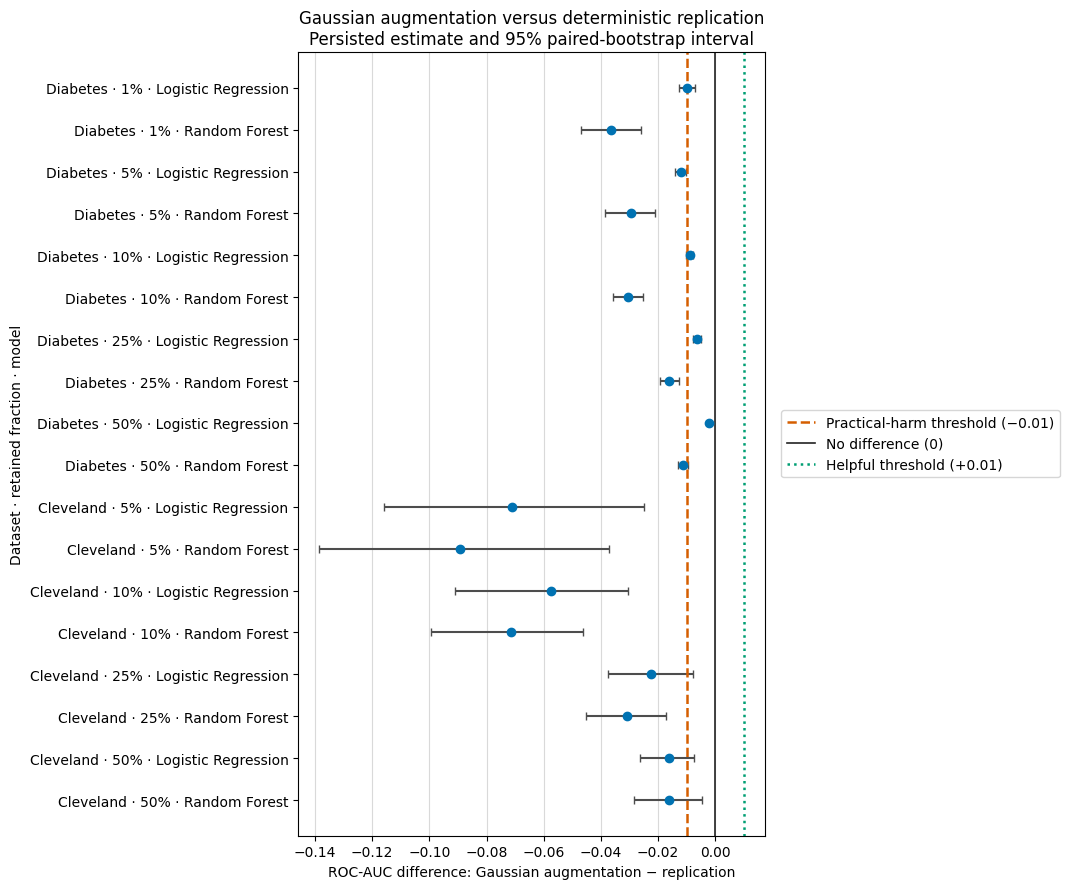

In [3]:
primary_rows = []
model_names = {"logistic_regression": "Logistic Regression", "random_forest": "Random Forest"}
for row in summary["rows"]:
    result = row["contrasts"]["gaussian_minus_replication"]
    primary_rows.append({
        "dataset": row["dataset"].title(),
        "retained_fraction": row["retained_fraction"],
        "model": model_names[row["model"]],
        "estimate": result["estimate"],
        "ci_lower": result["ci_lower"],
        "ci_upper": result["ci_upper"],
        "interpretation": result["interpretation"],
    })

plot_rows = list(reversed(primary_rows))
y = list(range(len(plot_rows)))
estimates = [row["estimate"] for row in plot_rows]
lower_error = [row["estimate"] - row["ci_lower"] for row in plot_rows]
upper_error = [row["ci_upper"] - row["estimate"] for row in plot_rows]
labels = [f'{row["dataset"]} · {row["retained_fraction"]:.0%} · {row["model"]}' for row in plot_rows]

fig, ax = plt.subplots(figsize=(14, 9))
ax.errorbar(estimates, y, xerr=[lower_error, upper_error], fmt="o", color="#0072B2", ecolor="#4D4D4D", capsize=3, markersize=6)
ax.axvline(-0.01, color="#D55E00", linestyle="--", linewidth=1.8, label="Practical-harm threshold (−0.01)")
ax.axvline(0.0, color="#222222", linestyle="-", linewidth=1.2, label="No difference (0)")
ax.axvline(0.01, color="#009E73", linestyle=":", linewidth=1.8, label="Helpful threshold (+0.01)")
ax.set_yticks(y, labels)
ax.set_xlabel("ROC-AUC difference: Gaussian augmentation − replication")
ax.set_ylabel("Dataset · retained fraction · model")
ax.set_title("Gaussian augmentation versus deterministic replication\nPersisted estimate and 95% paired-bootstrap interval")
ax.grid(axis="x", color="#D9D9D9", linewidth=0.8)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
fig.tight_layout(rect=(0, 0, 0.78, 1))
plt.show()

## 18-stratum primary-result table

Values are rounded to four decimal places and retained fractions are shown as percentages for public readability. See the [accepted stratum-summary JSON](../results/analysis/replication_v1/stratum_summaries.json) for exact representations.

In [4]:
table_rows = []
for source_row, public_row in zip(summary["rows"], primary_rows):
    result = source_row["contrasts"]["gaussian_minus_replication"]
    table_rows.append({
        "Dataset": public_row["dataset"],
        "Retained fraction": f'{source_row["retained_fraction"]:.0%}',
        "Model": public_row["model"],
        "Paired seeds": source_row["paired_seed_count"],
        "Estimate": f'{result["estimate"]:.4f}',
        "CI lower": f'{result["ci_lower"]:.4f}',
        "CI upper": f'{result["ci_upper"]:.4f}',
        "Interpretation": display_names[result["interpretation"]],
    })
primary_table = pd.DataFrame(table_rows)
primary_table

,Dataset,Retained fraction,Model,Paired seeds,Estimate,CI lower,CI upper,Interpretation
0,Diabetes,1%,Logistic Regression,30,-0.0099,-0.0129,-0.0071,No clear practically meaningful difference
1,Diabetes,1%,Random Forest,30,-0.0364,-0.0471,-0.0258,Harmful
2,Diabetes,5%,Logistic Regression,30,-0.0120,-0.0142,-0.0101,Harmful
3,Diabetes,5%,Random Forest,30,-0.0295,-0.0384,-0.0212,Harmful
4,Diabetes,10%,Logistic Regression,30,-0.0090,-0.0102,-0.0078,No clear practically meaningful difference
5,Diabetes,10%,Random Forest,30,-0.0307,-0.0356,-0.0254,Harmful
6,Diabetes,25%,Logistic Regression,30,-0.0063,-0.0077,-0.0051,No clear practically meaningful difference
7,Diabetes,25%,Random Forest,30,-0.0160,-0.0195,-0.0128,Harmful
8,Diabetes,50%,Logistic Regression,30,-0.0022,-0.0026,-0.0019,No clear practically meaningful difference
9,Diabetes,50%,Random Forest,30,-0.0112,-0.0129,-0.0094,No clear practically meaningful difference


## Accepted scope and limitations

Replication itself was harmful in 7 strata, indicating that restoration without new information explains part, but not all, of the degradation.

The accepted limitations are:

- Two binary-classification datasets
- Two model families
- ROC-AUC only
- Frozen scarcity and restoration protocol
- Replication is a matched control, not a statistically neutral intervention
- No causal or universal synthetic-data claim

No p-values, multiplicity adjustment, post-hoc contrasts, exclusions, alternative thresholds, reruns, or raw prediction persistence were used.

Accepted records:

- [Analysis report](../results/analysis/replication_v1/analysis_report.json)
- [Analysis-evidence commit `198f2c5a…`](../../../commit/198f2c5a7730f724c4feca0555556fa9b9215fa5)
- [Scientific review record](../results/provenance/replication_analysis_review_v1.json)